# Dual Fast Extragradient Method for Monotone L-Lipschitz Operators

This code outlines the procedure for Lyapunov function discovery for the Dual Fast Extragradient Method (Dual-FEG), one of the dual methods proposed in "Optimal Acceleration for Minimax and Fixed-Point Problems is Not Unique" by Yoon, Kim, Suh and Ryu. We consider the monotone $L$-Lipschitz operator setting with $\alpha=1/L$ and $z_0=0$, and verify the residual bound $\|A(x_N)\|^2 \le \frac{4L^2}{N^2}\|x_0-x_\star\|^2$.


## Import the required libraries

In [1]:
import pepflow as pf
import pepflow.lyapunov_utils as lu
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display, Math

## Define the operator and parameters

In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")
A = pf.LipschitzMonotoneOperator(is_basis=True, tags=["A"], L=L)

## Write a function to return the PEPContext for Dual-FEG

In [3]:
def make_ctx_dual_feg(ctx_name: str, N: int | sp.Integer) -> pf.PEPContext:
    ctx = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    z = pf.Vector.zero().add_tag("z_0")
    A.set_zero_point("x_star")

    alpha = 1 / L
    for k in range(int(N)):
        coeff = sp.S(N - k - 1) / sp.S(N - k)

        x_half = x - alpha * z - alpha * A(x)
        x_half.add_tag(f"x_{k}.5")

        x_next = x_half - coeff * alpha * (A(x_half) - A(x))
        x_next.add_tag(f"x_{k + 1}")

        z_next = coeff * z - sp.S(1) / sp.S(N - k) * A(x_half)
        z_next.add_tag(f"z_{k + 1}")

        x = x_next
        z = z_next

    return ctx

## Numerical evidence showing that Dual-FEG converges at the rate $\|A(x_N)\|^2 \le \frac{4L^2\|x_0-x_\star\|^2}{N^2}$

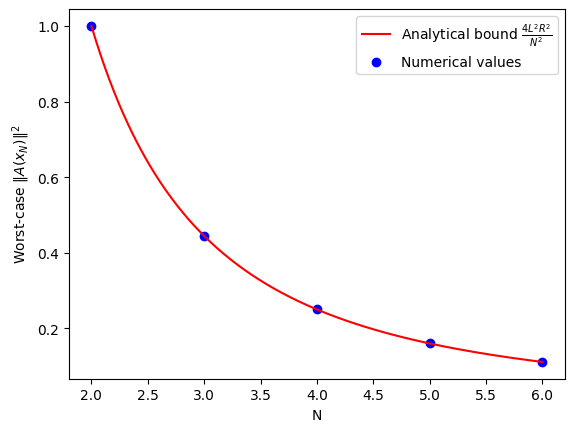

In [4]:
N_max = 6
L_value = 1
R_value = 1

opt_values = []
for N_i in range(2, N_max + 1):
    ctx_i = make_ctx_dual_feg(ctx_name=f"ctx_plt_{N_i}", N=N_i)
    pb_i = pf.PEPBuilder(ctx_i)
    pb_i.add_initial_constraint(
        ((ctx_i["x_0"] - ctx_i["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb_i.set_performance_metric(A(ctx_i[f"x_{N_i}"]) ** 2)
    result_i = pb_i.solve(resolve_parameters={"L": L_value, "R": R_value})
    opt_values.append(result_i.opt_value)

iters = np.arange(2, N_max + 1)
cont_iters = np.arange(2, N_max + 0.01, 0.01)
plt.plot(
    cont_iters,
    4 * L_value**2 * R_value**2 / cont_iters**2,
    "r-",
    label="Analytical bound $\\frac{4L^2R^2}{N^2}$",
)
plt.scatter(iters, opt_values, color="blue", marker="o", label="Numerical values")
plt.xlabel("N")
plt.ylabel(r"Worst-case $\|A(x_N)\|^2$")
plt.legend()

## Verification of convergence of Dual-FEG

In [5]:
N = sp.S(4)
L_value = sp.S(1)
R_value = sp.S(1)

ctx_prf = make_ctx_dual_feg("ctx_prf", N)
x_N_prf = ctx_prf[f"x_{N}"]
_ = A(x_N_prf)

pb_prf = pf.PEPBuilder(ctx_prf)
pb_prf.add_initial_constraint(
    ((ctx_prf["x_0"] - ctx_prf["x_star"]) ** 2).le(R_value**2, name="initial_condition")
)
pb_prf.set_performance_metric(A(x_N_prf) ** 2)
result = pb_prf.solve(resolve_parameters={"L": L_value, "R": R_value})
print(result.opt_value)

0.2500004040056194


### Store the solver output and matrix labels used below

In [6]:
# Dual variable associated with the initial condition.
tau_sol = result.dual_var_manager.dual_value("initial_condition")

# Dual variables associated with the interpolation conditions of A.
# We use these matrices for their row and column labels below.
lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(A)
lamb_mono_sol = lamb_sol["Monotone Operator Inequality"]
lamb_lip_sol = lamb_sol["Lipschitz Continuous Inequality"]

# Dual variable associated with the Gram matrix G.
S_sol = result.get_gram_dual_matrix()

In [7]:
print(lamb_mono_sol.row_names)
print(lamb_mono_sol.col_names)

['x_0', 'x_0.5', 'x_1', 'x_1.5', 'x_2', 'x_2.5', 'x_3', 'x_3.5', 'x_4']
['x_0.5', 'x_1', 'x_1.5', 'x_2', 'x_2.5', 'x_3', 'x_3.5', 'x_4', 'x_star']


In [8]:
S_sol.pprint()

<IPython.core.display.Math object>

### The Gram dual matrix $S$ has rank 1

In [9]:
np.linalg.matrix_rank(S_sol.matrix, tol=1e-7)

np.int64(3)

---

### Define the closed-form monotonicity and Lipschitz weights used in the certificate

In [10]:
def tag_to_index(tag, N=N):
    if tag == "x_star":
        return int(N) + 1
    idx = tag.split("_", 1)[1]
    if idx.endswith(".5"):
        return sp.Rational(2 * int(idx[:-2]) + 1, 2)
    return sp.Integer(idx)


def lamb_mono(tag_i, tag_j, N=N):
    i = tag_to_index(tag_i, N)
    j = tag_to_index(tag_j, N)
    for step in range(int(N) - 1):
        if i == sp.Rational(2 * step + 1, 2) and j == int(N):
            return sp.S(4) / ((N - step - 1) * (N - step))
    if i == int(N) and j == int(N) + 1:
        return sp.S(4) / N
    return 0


def lamb_lip(tag_i, tag_j, N=N):
    i = tag_to_index(tag_i, N)
    j = tag_to_index(tag_j, N)
    for step in range(int(N) - 1):
        if i == step and j == sp.Rational(2 * step + 1, 2):
            return sp.S(2) / (N - step) ** 2
    if i == int(N) - 1 and j == int(N):
        return sp.S(2)
    return 0

## Step 1. Propose a candidate Lyapunov function

### Choose $\mathcal{I}_k$ to contain the monotonicity inequalities $(x_{j+1/2},x_N)$ and the Lipschitz inequalities $(x_j,x_{j+1/2})$ for $j=0,\dots,k-1$. For $k=N$, add the terminal monotonicity inequality $(x_N,x_\star)$ and the terminal Lipschitz inequality $(x_{N-1},x_N)$.

In [11]:
lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for j in range(int(N)):
    if j < int(N) - 1:
        partial_sum += lamb_mono(f"x_{j}.5", f"x_{N}") * (
            -A.monotone_ineq(f"x_{j}.5", f"x_{N}", ctx_prf)
        )
        partial_sum += lamb_lip(f"x_{j}", f"x_{j}.5") * (
            -A.lipschitz_ineq(f"x_{j}", f"x_{j}.5", ctx_prf)
        )
    else:
        partial_sum += lamb_mono(f"x_{N}", "x_star") * (
            -A.monotone_ineq(f"x_{N}", "x_star", ctx_prf)
        )
        partial_sum += lamb_lip(f"x_{int(N) - 1}", f"x_{N}") * (
            -A.lipschitz_ineq(f"x_{int(N) - 1}", f"x_{N}", ctx_prf)
        )
    lyap.append(partial_sum)

## Step 2. Check for admissibility

### Sufficiency is immediate. ### To check rank consistency and conciseness, verify that the interior ranks of $\mathbf{V}_k$ are constantly 4 and that the terminal rank is 2.

In [12]:
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"L": L_value})

for k in range(len(lyap)):
    lyap_numeric_k = pm.eval_scalar(lyap[k]).inner_prod_coords.astype(float)
    print(f"Rank of lyap[{k}]: {np.linalg.matrix_rank(lyap_numeric_k, tol=1e-6)}")

Rank of lyap[0]: 0
Rank of lyap[1]: 4
Rank of lyap[2]: 4
Rank of lyap[3]: 4
Rank of lyap[4]: 2


## Step 3. Build a set of special candidate vectors

In [13]:
lyap_basis_candidate = ctx_prf.basis_vectors()
lyap_basis_candidate += [ctx_prf[f"x_{i}"] for i in range(1, int(N) + 1)]
lyap_basis_candidate += [ctx_prf[f"z_{i}"] for i in range(1, int(N) + 1)]
lyap_basis_candidate += [ctx_prf[f"x_{i}.5"] for i in range(int(N))]

for i, j in combinations(range(len(lyap_basis_candidate)), 2):
    diff = lyap_basis_candidate[i] - lyap_basis_candidate[j]
    diff.add_tag(f"{lyap_basis_candidate[i]}-{lyap_basis_candidate[j]}")
    lyap_basis_candidate.append(diff)

In [14]:
print(lyap_basis_candidate)

[x_0, x_star, A(x_0), A(x_0.5), A(x_1), A(x_1.5), A(x_2), A(x_2.5), A(x_3), A(x_3.5), A(x_4), x_1, x_2, x_3, x_4, z_1, z_2, z_3, z_4, x_0.5, x_1.5, x_2.5, x_3.5, x_0-x_star, x_0-A(x_0), x_0-A(x_0.5), x_0-A(x_1), x_0-A(x_1.5), x_0-A(x_2), x_0-A(x_2.5), x_0-A(x_3), x_0-A(x_3.5), x_0-A(x_4), x_0-x_1, x_0-x_2, x_0-x_3, x_0-x_4, x_0-z_1, x_0-z_2, x_0-z_3, x_0-z_4, x_0-x_0.5, x_0-x_1.5, x_0-x_2.5, x_0-x_3.5, x_star-A(x_0), x_star-A(x_0.5), x_star-A(x_1), x_star-A(x_1.5), x_star-A(x_2), x_star-A(x_2.5), x_star-A(x_3), x_star-A(x_3.5), x_star-A(x_4), x_star-x_1, x_star-x_2, x_star-x_3, x_star-x_4, x_star-z_1, x_star-z_2, x_star-z_3, x_star-z_4, x_star-x_0.5, x_star-x_1.5, x_star-x_2.5, x_star-x_3.5, A(x_0)-A(x_0.5), A(x_0)-A(x_1), A(x_0)-A(x_1.5), A(x_0)-A(x_2), A(x_0)-A(x_2.5), A(x_0)-A(x_3), A(x_0)-A(x_3.5), A(x_0)-A(x_4), A(x_0)-x_1, A(x_0)-x_2, A(x_0)-x_3, A(x_0)-x_4, A(x_0)-z_1, A(x_0)-z_2, A(x_0)-z_3, A(x_0)-z_4, A(x_0)-x_0.5, A(x_0)-x_1.5, A(x_0)-x_2.5, A(x_0)-x_3.5, A(x_0.5)-A(x_1), A(

## Step 4. Find a basis of $\mathbf{V}_k$ within lyap_basis_candidate

In [15]:
for k in range(len(lyap)):
    print(
        f"V_{k}:",
        lu.vectors_in_column_space(
            lyap[k],
            lyap_basis_candidate,
            ctx_prf,
            resolve_parameters=pm.resolve_parameters,
            rtol=1e-6,
            atol=1e-6,
        ),
    )

V_0: [x_4-x_3.5]
V_1: [A(x_0), A(x_0.5), A(x_4), z_1, x_0-x_1, x_0-x_4, x_0-x_0.5, x_0-x_3.5, A(x_0)-A(x_0.5), A(x_0)-A(x_4), A(x_0)-z_1, A(x_0.5)-A(x_4), A(x_0.5)-z_1, A(x_4)-z_1, x_1-x_4, x_1-x_0.5, x_1-x_3.5, x_4-x_0.5, x_4-x_3.5, x_0.5-x_3.5]
V_2: [A(x_4), z_2, x_0-x_2, x_0-x_4, x_0-x_3.5, A(x_4)-z_2, x_2-x_4, x_2-x_3.5, x_4-x_3.5]
V_3: [A(x_3), A(x_4), z_3, x_0-x_3, x_0-x_4, x_0-x_3.5, A(x_2.5)-z_2, A(x_3)-A(x_4), A(x_3)-z_3, A(x_4)-z_3, x_3-x_4, x_3-x_3.5, x_4-x_3.5]
V_4: [A(x_4), x_0-x_star, x_4-x_3.5]


### We find that $x_0-x_N$, $x_k-x_N$, $z_k$, and $A(x_N)$ are the correct vectors for $V_k$ when $1\le k<N$. For the terminal $V_N$, the correct vectors are $x_0-x_\star$ and $A(x_N)$.

In [16]:
def V_k_basis(k: int):
    if k < int(N):
        return [
            ctx_prf["x_0"] - ctx_prf[f"x_{N}"],
            ctx_prf[f"x_{k}"] - ctx_prf[f"x_{N}"],
            ctx_prf[f"z_{k}"],
            A(ctx_prf[f"x_{N}"]),
        ]
    return [ctx_prf["x_0"] - ctx_prf["x_star"], A(ctx_prf[f"x_{N}"])]


for k in np.arange(1, len(lyap)):
    aligned_special_vectors_k = V_k_basis(int(k))
    C_k = lu.find_symmetric_coefficient_matrix(
        lyap[k],
        aligned_special_vectors_k,
        pep_context=ctx_prf,
        resolve_parameters=pm.resolve_parameters,
    )
    labels_k = [str(v) for v in aligned_special_vectors_k]
    print(f"V_{k}:")
    pf.pprint_labeled_matrix(C_k, labels_k, labels_k)

V_1:


<IPython.core.display.Math object>

V_2:


<IPython.core.display.Math object>

V_3:


<IPython.core.display.Math object>

V_4:


<IPython.core.display.Math object>

---

## Step 5. Analytic proof

### We use the closed-form monotonicity weights, the Lipschitz weights, and $S$ suggested by the Lyapunov certificate.

### Candidate formula for monotonicity weights

In [17]:
lamb_mono_cand = pf.pprint_labeled_matrix(
    lamb_mono,
    lamb_mono_sol.row_names,
    lamb_mono_sol.col_names,
    return_matrix=True,
)

<IPython.core.display.Math object>

### Candidate formula for Lipschitz weights

In [18]:
lamb_lip_cand = pf.pprint_labeled_matrix(
    lamb_lip,
    lamb_lip_sol.row_names,
    lamb_lip_sol.col_names,
    return_matrix=True,
)

<IPython.core.display.Math object>

### Candidate formula for $S$ used in the boundary identity

In [19]:
x_0 = ctx_prf["x_0"]
x_N = ctx_prf[f"x_{N}"]
x_star = ctx_prf["x_star"]

S_guess = (A(x_N) - sp.S(2) / N * (x_0 - x_star)) ** 2
S_guess_eval = pm.eval_scalar(S_guess).matrix
pf.pprint_labeled_matrix(S_guess_eval, S_sol.row_names, S_sol.col_names)

<IPython.core.display.Math object>

### Finally, we symbolically determine the Lyapunov function coefficients

In [20]:
ctx_dual_feg_lyap = pf.PEPContext("dual_feg_lyap_finder").set_as_current()

### Express $V_{k+1}-V_k$ minus the weighted monotonicity and Lipschitz inequalities as a system of equations and solve for the Lyapunov coefficients.

In [21]:
k = pf.Parameter("k")
N_sym = pf.Parameter("N")
L_sym = sp.S(1)

x_0_minus_x_N = pf.Vector(is_basis=True, tags=["x_0-x_N"])
x_k_minus_x_N = pf.Vector(is_basis=True, tags=["x_k-x_N"])
z_k = pf.Vector(is_basis=True, tags=["z_k"])
A_x_k = pf.Vector(is_basis=True, tags=["A(x_k)"])
A_x_half = pf.Vector(is_basis=True, tags=["A(x_{k+1/2})"])
A_x_N = pf.Vector(is_basis=True, tags=["A(x_N)"])

coeff = (N_sym - k - 1) / (N_sym - k)
x_half_minus_x_N = x_k_minus_x_N - z_k / L_sym - A_x_k / L_sym
x_k_minus_x_half = (z_k + A_x_k) / L_sym
x_k1_minus_x_N = x_half_minus_x_N - coeff / L_sym * (A_x_half - A_x_k)
z_k1 = coeff * z_k - sp.S(1) / (N_sym - k) * A_x_half

a_k = pf.Parameter("a_k")
a_k1 = pf.Parameter("a_{k+1}")
b_k = pf.Parameter("b_k")
b_k1 = pf.Parameter("b_{k+1}")
c_k = pf.Parameter("c_k")
c_k1 = pf.Parameter("c_{k+1}")
d_k = pf.Parameter("d_k")
d_k1 = pf.Parameter("d_{k+1}")
e_k = pf.Parameter("e_k")
e_k1 = pf.Parameter("e_{k+1}")

V_k = (
    a_k * (x_0_minus_x_N * A_x_N)
    + b_k * (x_k_minus_x_N * z_k)
    + c_k * (x_k_minus_x_N * A_x_N)
    + d_k * (z_k**2)
    + e_k * (z_k * A_x_N)
)
V_k1 = (
    a_k1 * (x_0_minus_x_N * A_x_N)
    + b_k1 * (x_k1_minus_x_N * z_k1)
    + c_k1 * (x_k1_minus_x_N * A_x_N)
    + d_k1 * (z_k1**2)
    + e_k1 * (z_k1 * A_x_N)
)

mono_step = -(x_half_minus_x_N * (A_x_half - A_x_N))
lip_step = (A_x_k - A_x_half) ** 2 - L_sym**2 * (x_k_minus_x_half**2)
diff = V_k1 - V_k

diff -= 4 / ((N_sym - k - 1) * (N_sym - k)) * mono_step
diff -= 2 / (N_sym - k) ** 2 * lip_step

In [22]:
basis = ctx_dual_feg_lyap.basis_vectors()
row_index = [str(v) for v in basis]
row_index

['x_0-x_N', 'x_k-x_N', 'z_k', 'A(x_k)', 'A(x_{k+1/2})', 'A(x_N)']

In [23]:
pm_lyap = pf.ExpressionManager(
    ctx_dual_feg_lyap,
    resolve_parameters={
        "a_k": sp.Symbol("a_k"),
        "a_{k+1}": sp.Symbol("a_{k+1}"),
        "b_k": sp.Symbol("b_k"),
        "b_{k+1}": sp.Symbol("b_{k+1}"),
        "c_k": sp.Symbol("c_k"),
        "c_{k+1}": sp.Symbol("c_{k+1}"),
        "d_k": sp.Symbol("d_k"),
        "d_{k+1}": sp.Symbol("d_{k+1}"),
        "e_k": sp.Symbol("e_k"),
        "e_{k+1}": sp.Symbol("e_{k+1}"),
        "N": sp.Symbol("N"),
        "k": sp.Symbol("k"),
    },
)

diff_matrix = pm_lyap.eval_scalar(diff).inner_prod_coords
pf.pprint_labeled_matrix(diff_matrix, row_index, row_index, precision=None)

<IPython.core.display.Math object>

In [24]:
diff_matrix_sympify = sp.Matrix(diff_matrix)

unknowns = sp.symbols("a_k a_{k+1} b_k b_{k+1} c_k c_{k+1} d_k d_{k+1} e_k e_{k+1}")
eqs = list(diff_matrix_sympify)
sol = sp.linsolve(eqs, unknowns)
sol_simplify = sp.factor(sp.nsimplify(sol))

print("Solutions:")
sol_dict = dict(zip(unknowns, next(iter(sol_simplify))))
display(Math(sp.latex(sol_dict)))

Solutions:


<IPython.core.display.Math object>

### The consistent solution is $a_k=-\frac{4}{N}$, $b_k=c_k=\frac{4}{N-k}$, $d_k=-2$, and $e_k=-4$, so
$$
\begin{aligned}
V_k={}&-\frac{4}{N}\langle x_0-x_N,A(x_N)\rangle
+\frac{4}{N-k}\langle x_k-x_N,z_k\rangle
+\frac{4}{N-k}\langle x_k-x_N,A(x_N)\rangle\\
&-2\|z_k\|^2-4\langle z_k,A(x_N)\rangle.
\end{aligned}
$$

### Plug the computed coefficients back into
$$
V_{k+1}-V_k = \frac{4}{(N-k-1)(N-k)}M(x_{k+1/2},x_N) + \frac{2}{(N-k)^2}Q(x_k,x_{k+1/2}).
$$
### This verifies that everything cancels out symbolically.

In [25]:
if sol:
    print("\nVerification:")
    display(sp.simplify(diff_matrix_sympify.subs(sol_dict)))


Verification:


Matrix([
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0]])